# Klasifikasi Penyakit Daun Kentang dengan ResNet50 dan SVM

Notebook ini membangun pipeline klasifikasi tiga kelas:

**Citra → preprocessing ImageNet → fitur ResNet50 (2048 dimensi) → pipeline scikit-learn → SVM**

ResNet50 hanya dipakai sebagai feature extractor. Classifier akhir tetap Support Vector Machine (SVM). Seluruh pemilihan model dilakukan pada data training; test set dipakai satu kali untuk evaluasi akhir.

## 1. Project Setup

Jalankan notebook dari root project, yaitu direktori yang berisi folder dataset. Semua path dibuat relatif agar project mudah dipindahkan.

## 2. Import Library

In [1]:
import hashlib
import json
import os
import platform
import random
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from IPython.display import Markdown, display
from PIL import Image, ImageFile
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
ImageFile.LOAD_TRUNCATED_IMAGES = False

## 3. Configuration dan Reproducibility

Nilai acak dikunci untuk Python, NumPy, PyTorch, dan CUDA. Opsi deterministic membantu reproduksibilitas, walaupun hasil lintas versi library/perangkat keras masih dapat sedikit berbeda.

In [ ]:
RANDOM_STATE = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
TEST_SIZE = 0.20
DATASET_PATH = Path("dataset")
MODEL_DIR = Path("models")
PIPELINE_CACHE_DIR = Path(".cache") / "sklearn"
NUM_WORKERS = 0  # Aman untuk Windows + Jupyter
N_JOBS = -1      # Ubah ke 1 jika RAM terbatas
CV_SPLITS = 5
USE_AUGMENTATION = False

CLASS_FOLDER_TO_LABEL = {
    "Potato___Early_blight": "Early Blight",
    "Potato___Late_blight": "Late Blight",
    "Potato___healthy": "Healthy",
}
CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PIPELINE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)

print(f"Python              : {sys.version.split()[0]}")
print(f"Platform            : {platform.platform()}")
print(f"PyTorch             : {torch.__version__}")
print(f"torchvision         : {torchvision.__version__}")
print(f"scikit-learn        : {sklearn.__version__}")
print(f"CUDA tersedia       : {torch.cuda.is_available()}")
print(f"Device              : {device}")
if torch.cuda.is_available():
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

Python              : 3.10.0
Platform            : Windows-10-10.0.26200-SP0
PyTorch             : 2.11.0+cu128
torchvision         : 0.26.0+cu128
scikit-learn        : 1.7.0
CUDA tersedia       : True
Device              : cuda
GPU                 : NVIDIA GeForce RTX 3060 Laptop GPU


## 4. Dataset Loading

File dipindai otomatis. Hanya JPG, JPEG, dan PNG yang dimasukkan. Mapping folder ke label manusia dibuat eksplisit agar urutan kelas konsisten.

In [3]:
def scan_dataset(dataset_path: Path) -> pd.DataFrame:
    if not dataset_path.exists() or not dataset_path.is_dir():
        raise FileNotFoundError(
            f"Folder dataset tidak ditemukan: {dataset_path.resolve()}"
        )

    available_folders = {path.name for path in dataset_path.iterdir() if path.is_dir()}
    missing_folders = set(CLASS_FOLDER_TO_LABEL) - available_folders
    if missing_folders:
        raise FileNotFoundError(
            f"Folder kelas belum lengkap. Tidak ditemukan: {sorted(missing_folders)}"
        )

    records = []
    for folder_name, clean_label in CLASS_FOLDER_TO_LABEL.items():
        class_dir = dataset_path / folder_name
        for image_path in sorted(class_dir.rglob("*")):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append(
                    {
                        "image_path": image_path.as_posix(),
                        "label": clean_label,
                        "filename": image_path.name,
                        "class_folder": folder_name,
                    }
                )

    dataframe = pd.DataFrame(records)
    if dataframe.empty:
        raise ValueError("Tidak ada file gambar JPG/JPEG/PNG di dalam dataset.")
    return dataframe


raw_df = scan_dataset(DATASET_PATH)
print(f"Jumlah kandidat gambar: {len(raw_df):,}")
display(raw_df.head())

Jumlah kandidat gambar: 2,152


,image_path,label,filename,class_folder
0,dataset/Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG,Early Blight,001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG,Potato___Early_blight
1,dataset/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG,Early Blight,002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG,Potato___Early_blight
2,dataset/Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG,Early Blight,009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG,Potato___Early_blight
3,dataset/Potato___Early_blight/00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG,Early Blight,00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG,Potato___Early_blight
4,dataset/Potato___Early_blight/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG,Early Blight,0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG,Potato___Early_blight


## 5. Dataset Validation

Setiap file diverifikasi dengan Pillow, lalu dibaca ulang untuk memperoleh dimensi, mode, ukuran file, aspect ratio, dan hash MD5. File rusak dicatat tanpa menghentikan notebook.

In [4]:
def inspect_image(image_path: str) -> dict:
    path = Path(image_path)
    with Image.open(path) as image:
        image.verify()

    with Image.open(path) as image:
        width, height = image.size
        mode = image.mode

    file_hash = hashlib.md5(path.read_bytes()).hexdigest()
    return {
        "image_path": image_path,
        "extension": path.suffix.lower(),
        "width": width,
        "height": height,
        "aspect_ratio": width / height,
        "image_mode": mode,
        "file_size_kb": path.stat().st_size / 1024,
        "md5": file_hash,
    }


valid_records = []
invalid_records = []

for row in tqdm(raw_df.itertuples(index=False), total=len(raw_df), desc="Validasi gambar"):
    try:
        valid_records.append(inspect_image(row.image_path))
    except Exception as error:
        invalid_records.append(
            {
                "image_path": row.image_path,
                "label": row.label,
                "error": repr(error),
            }
        )

image_metadata_df = pd.DataFrame(valid_records)
invalid_df = pd.DataFrame(
    invalid_records,
    columns=["image_path", "label", "error"],
)
valid_df = raw_df.merge(image_metadata_df, on="image_path", how="inner")

print(f"File valid   : {len(valid_df):,}")
print(f"File invalid : {len(invalid_df):,}")
if not invalid_df.empty:
    display(invalid_df)

Validasi gambar:   0%|          | 0/2152 [00:00<?, ?it/s]

File valid   : 2,152
File invalid : 0


## 6. Exploratory Data Analysis

### 6.1 Ringkasan Dataset dan Distribusi Kelas

Macro F1 dan balanced accuracy akan diprioritaskan karena ukuran kelas tidak seimbang.

In [5]:
class_summary = (
    valid_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename("jumlah")
    .to_frame()
)
class_summary["persentase"] = 100 * class_summary["jumlah"] / len(valid_df)
class_summary.index.name = "kelas"

print(f"Total gambar valid : {len(valid_df):,}")
print(f"Jumlah kelas       : {valid_df['label'].nunique()}")
display(class_summary.style.format({"persentase": "{:.2f}%"}))

Total gambar valid : 2,152
Jumlah kelas       : 3


,jumlah,persentase
kelas,,
Early Blight,1000,46.47%
Late Blight,1000,46.47%
Healthy,152,7.06%


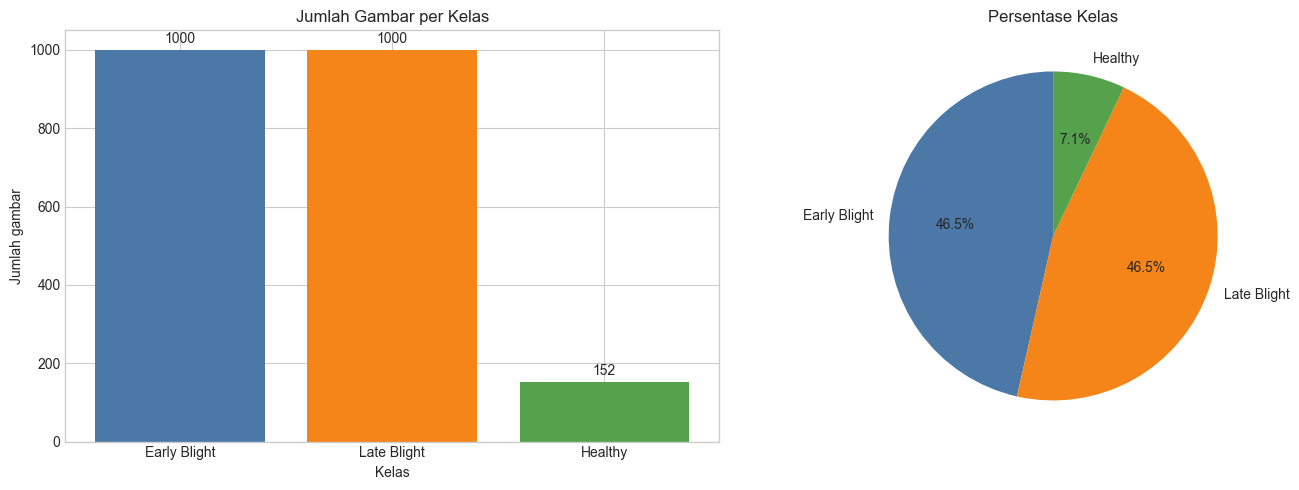

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    class_summary.index,
    class_summary["jumlah"],
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Jumlah Gambar per Kelas")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah gambar")

axes[1].pie(
    class_summary["jumlah"],
    labels=class_summary.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F58518", "#54A24B"],
)
axes[1].set_title("Persentase Kelas")
plt.tight_layout()
plt.show()

### 6.2 Contoh Gambar per Kelas

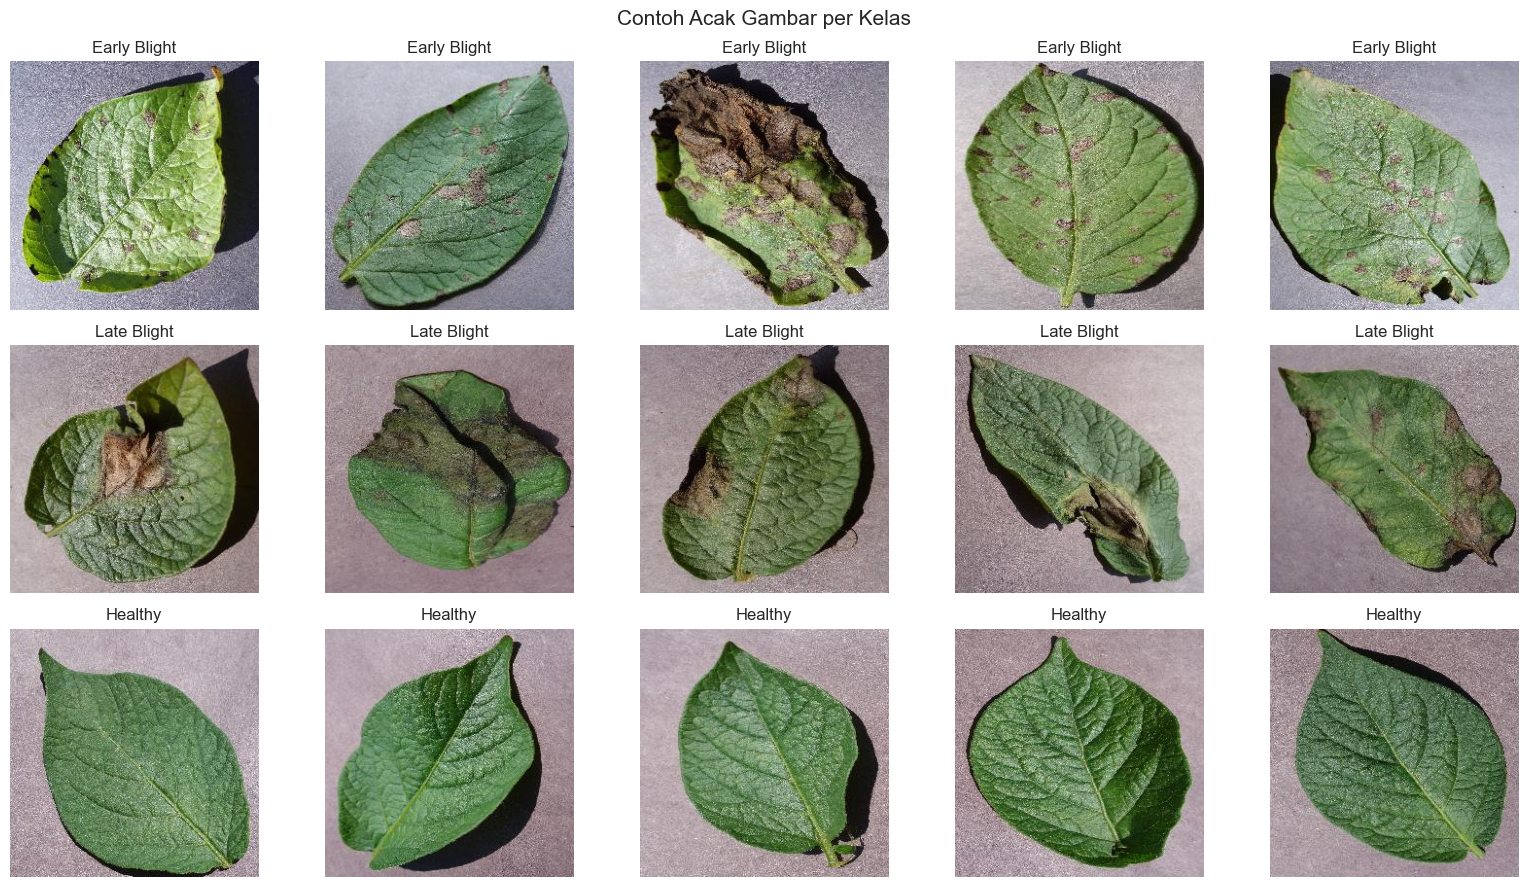

In [7]:
n_examples = 5
fig, axes = plt.subplots(len(CLASS_NAMES), n_examples, figsize=(16, 9))

for row_index, class_name in enumerate(CLASS_NAMES):
    class_rows = valid_df[valid_df["label"] == class_name]
    samples = class_rows.sample(
        n=min(n_examples, len(class_rows)),
        random_state=RANDOM_STATE,
    )

    for column_index in range(n_examples):
        axis = axes[row_index, column_index]
        axis.axis("off")
        if column_index < len(samples):
            sample = samples.iloc[column_index]
            with Image.open(sample["image_path"]) as image:
                axis.imshow(image.convert("RGB"))
            axis.set_title(class_name)

fig.suptitle("Contoh Acak Gambar per Kelas", fontsize=15)
plt.tight_layout()
plt.show()

### 6.3 Analisis Dimensi dan Aspect Ratio

In [8]:
dimension_summary = valid_df[["width", "height", "aspect_ratio"]].describe().T
most_common_sizes = (
    valid_df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .rename("jumlah")
    .head(10)
)

display(dimension_summary)
print("10 ukuran paling umum:")
display(most_common_sizes.to_frame())

,count,mean,std,min,25%,50%,75%,max
width,2152.0,256.0,0.0,256.0,256.0,256.0,256.0,256.0
height,2152.0,256.0,0.0,256.0,256.0,256.0,256.0,256.0
aspect_ratio,2152.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


10 ukuran paling umum:


,,jumlah
width,height,
256,256,2152


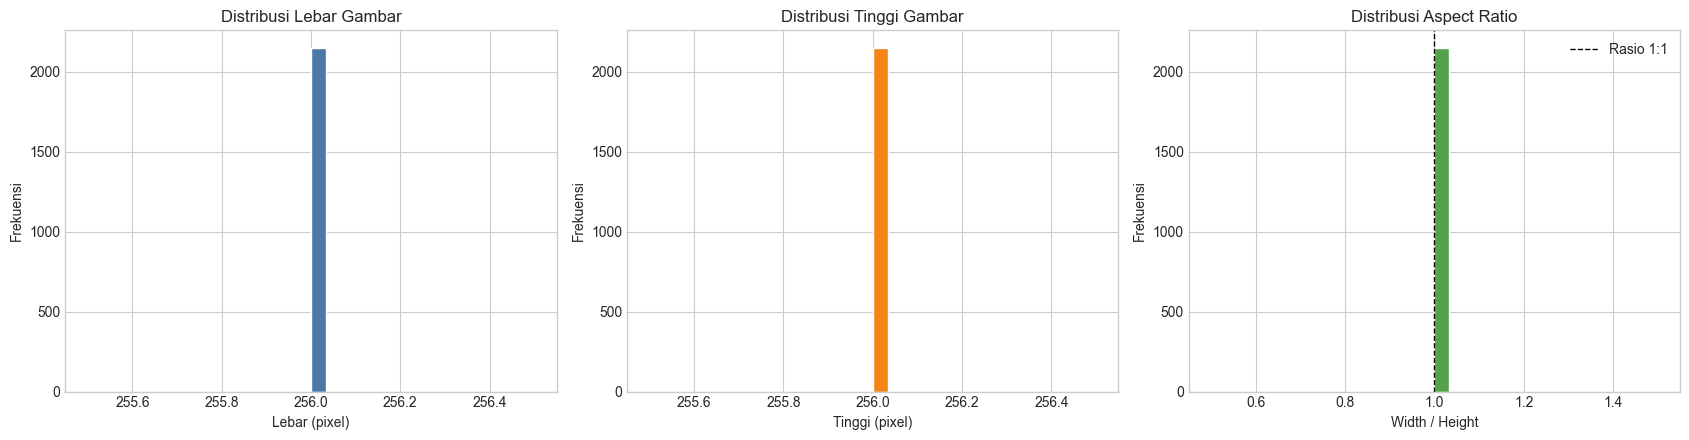

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(valid_df["width"], bins=30, color="#4C78A8", edgecolor="white")
axes[0].set_title("Distribusi Lebar Gambar")
axes[0].set_xlabel("Lebar (pixel)")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(valid_df["height"], bins=30, color="#F58518", edgecolor="white")
axes[1].set_title("Distribusi Tinggi Gambar")
axes[1].set_xlabel("Tinggi (pixel)")
axes[1].set_ylabel("Frekuensi")

axes[2].hist(valid_df["aspect_ratio"], bins=30, color="#54A24B", edgecolor="white")
axes[2].axvline(1.0, color="black", linestyle="--", linewidth=1, label="Rasio 1:1")
axes[2].set_title("Distribusi Aspect Ratio")
axes[2].set_xlabel("Width / Height")
axes[2].set_ylabel("Frekuensi")
axes[2].legend()

plt.tight_layout()
plt.show()

### 6.4 Mode Warna dan Ekstensi

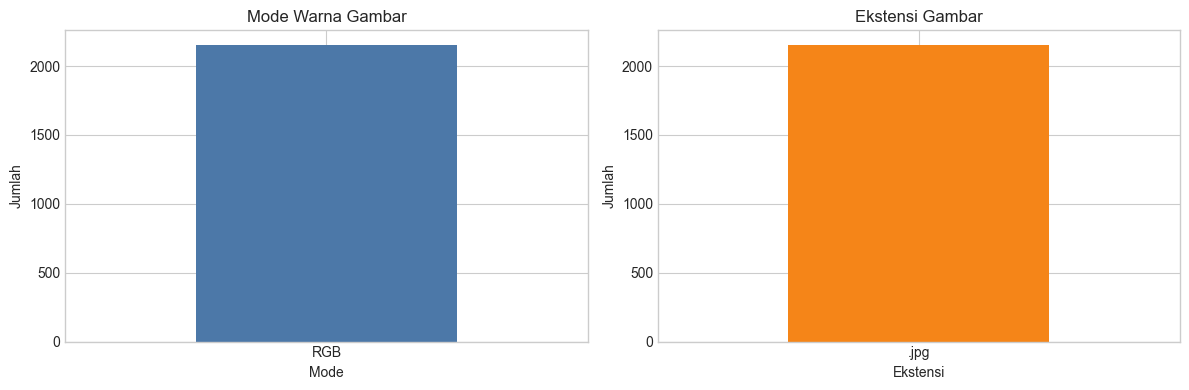

In [10]:
mode_counts = valid_df["image_mode"].value_counts()
extension_counts = valid_df["extension"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mode_counts.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Mode Warna Gambar")
axes[0].set_xlabel("Mode")
axes[0].set_ylabel("Jumlah")
axes[0].tick_params(axis="x", rotation=0)

extension_counts.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Ekstensi Gambar")
axes[1].set_xlabel("Ekstensi")
axes[1].set_ylabel("Jumlah")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 6.5 Analisis Intensitas Pixel

Agar hemat memori, analisis memakai sampel maksimal 40 gambar per kelas yang dikecilkan ke 128 × 128. Ini cukup untuk melihat kecenderungan warna, bukan untuk melatih model.

In [11]:
pixel_sample_df = pd.concat(
    [
        group.sample(
            n=min(40, len(group)),
            random_state=RANDOM_STATE,
        )
        for _, group in valid_df.groupby("label", sort=False)
    ],
    ignore_index=True,
)

channel_pixels = []
image_color_stats = []

for row in tqdm(
    pixel_sample_df.itertuples(index=False),
    total=len(pixel_sample_df),
    desc="Analisis pixel",
):
    with Image.open(row.image_path) as image:
        rgb_array = np.asarray(image.convert("RGB").resize((128, 128)), dtype=np.uint8)

    channel_pixels.append(rgb_array.reshape(-1, 3))
    image_color_stats.append(
        {
            "label": row.label,
            "mean_r": rgb_array[:, :, 0].mean(),
            "mean_g": rgb_array[:, :, 1].mean(),
            "mean_b": rgb_array[:, :, 2].mean(),
            "std_r": rgb_array[:, :, 0].std(),
            "std_g": rgb_array[:, :, 1].std(),
            "std_b": rgb_array[:, :, 2].std(),
        }
    )

sampled_pixels = np.concatenate(channel_pixels, axis=0)
color_stats_df = pd.DataFrame(image_color_stats)

display(
    color_stats_df.groupby("label")
    .mean()
    .reindex(CLASS_NAMES)
    .round(2)
)

Analisis pixel:   0%|          | 0/120 [00:00<?, ?it/s]

,mean_r,mean_g,mean_b,std_r,std_g,std_b
label,,,,,,
Early Blight,135.62,141.15,115.13,44.45,43.41,54.62
Late Blight,117.48,119.89,105.39,39.51,32.63,45.02
Healthy,125.93,134.10,113.41,47.12,30.74,48.93


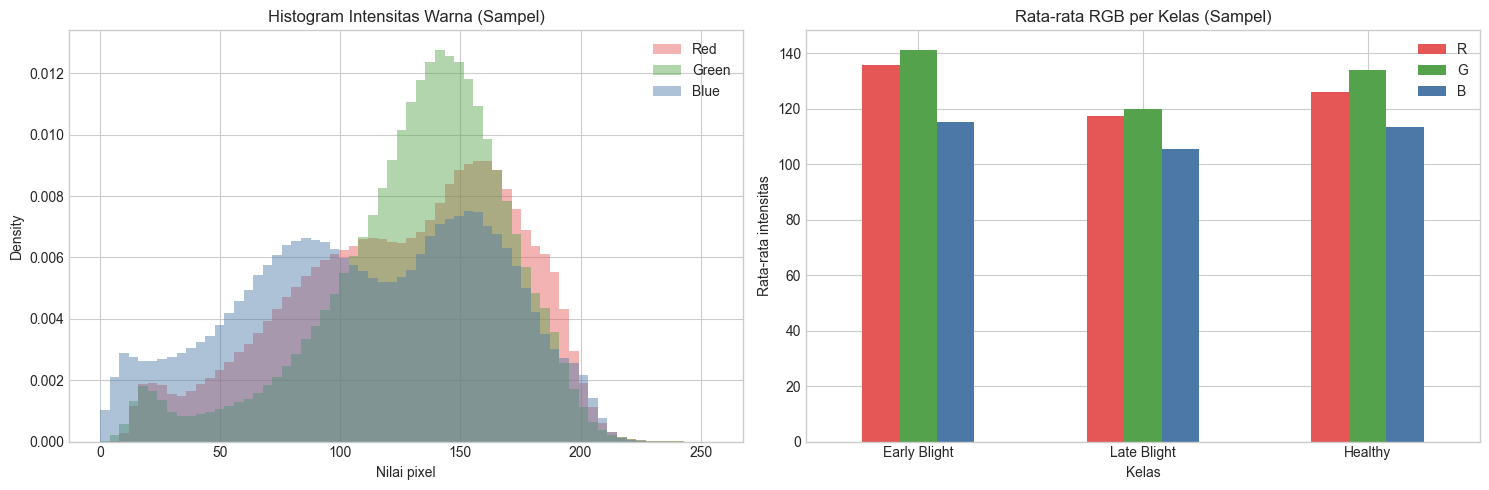

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
channel_info = [
    (0, "Red", "#E45756"),
    (1, "Green", "#54A24B"),
    (2, "Blue", "#4C78A8"),
]

for channel_index, channel_name, color in channel_info:
    axes[0].hist(
        sampled_pixels[:, channel_index],
        bins=64,
        range=(0, 255),
        alpha=0.45,
        density=True,
        label=channel_name,
        color=color,
    )
axes[0].set_title("Histogram Intensitas Warna (Sampel)")
axes[0].set_xlabel("Nilai pixel")
axes[0].set_ylabel("Density")
axes[0].legend()

class_rgb_means = (
    color_stats_df.groupby("label")[["mean_r", "mean_g", "mean_b"]]
    .mean()
    .reindex(CLASS_NAMES)
)
class_rgb_means.plot(
    kind="bar",
    ax=axes[1],
    color=["#E45756", "#54A24B", "#4C78A8"],
)
axes[1].set_title("Rata-rata RGB per Kelas (Sampel)")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Rata-rata intensitas")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["R", "G", "B"])

plt.tight_layout()
plt.show()

### 6.6 Analisis Ketidakseimbangan Kelas

In [13]:
largest_class = int(class_summary["jumlah"].max())
smallest_class = int(class_summary["jumlah"].min())
imbalance_ratio = largest_class / smallest_class

print(f"Rasio kelas terbesar : terkecil = {imbalance_ratio:.2f} : 1")
if imbalance_ratio >= 2:
    print(
        "Dataset tidak seimbang. Karena itu model memakai class_weight='balanced' "
        "dan metrik utama Macro F1. Oversampling tidak dilakukan sebelum split."
    )
else:
    print("Ketidakseimbangan kelas relatif ringan.")

Rasio kelas terbesar : terkecil = 6.58 : 1
Dataset tidak seimbang. Karena itu model memakai class_weight='balanced' dan metrik utama Macro F1. Oversampling tidak dilakukan sebelum split.


## 7. Duplicate Image Check

Hash MD5 mendeteksi duplikat byte-identik. Duplikat berlabel sama disimpan satu kali sebelum split; hash yang muncul pada beberapa label dikeluarkan seluruhnya karena labelnya ambigu. Langkah ini mencegah citra identik masuk ke train dan test.

In [14]:
duplicate_rows = valid_df[valid_df.duplicated("md5", keep=False)].sort_values("md5")
conflicting_hashes = (
    duplicate_rows.groupby("md5")["label"].nunique().loc[lambda values: values > 1].index
)

n_duplicate_extra_files = int(valid_df.duplicated("md5", keep="first").sum())
print(f"File duplikat tambahan     : {n_duplicate_extra_files}")
print(f"Hash dengan konflik label  : {len(conflicting_hashes)}")

if not duplicate_rows.empty:
    display(
        duplicate_rows[
            ["image_path", "label", "md5"]
        ].head(20)
    )

File duplikat tambahan     : 0
Hash dengan konflik label  : 0


## 8. Data Preparation

In [15]:
model_df = (
    valid_df.loc[~valid_df["md5"].isin(conflicting_hashes)]
    .drop_duplicates(subset="md5", keep="first")
    .reset_index(drop=True)
)

removed_count = len(valid_df) - len(model_df)
print(f"Gambar valid awal       : {len(valid_df):,}")
print(f"Gambar dikeluarkan      : {removed_count:,}")
print(f"Gambar untuk pemodelan  : {len(model_df):,}")

remaining_counts = model_df["label"].value_counts().reindex(CLASS_NAMES)
if remaining_counts.isna().any() or (remaining_counts < 2).any():
    raise ValueError("Setiap kelas memerlukan minimal dua gambar setelah deduplikasi.")
display(remaining_counts.rename("jumlah").to_frame())

Gambar valid awal       : 2,152
Gambar dikeluarkan      : 0
Gambar untuk pemodelan  : 2,152


,jumlah
label,
Early Blight,1000
Late Blight,1000
Healthy,152


## 9. Train-Test Split

Split dilakukan sebelum scaler, PCA, tuning, dan augmentasi. Stratifikasi menjaga proporsi kelas. Test set tidak dipakai untuk keputusan apa pun sampai bagian evaluasi final.

In [16]:
train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=model_df["label"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_distribution = pd.concat(
    {
        "Train": train_df["label"].value_counts().reindex(CLASS_NAMES),
        "Test": test_df["label"].value_counts().reindex(CLASS_NAMES),
    },
    axis=1,
)
split_distribution["Train %"] = (
    100 * split_distribution["Train"] / split_distribution["Train"].sum()
)
split_distribution["Test %"] = (
    100 * split_distribution["Test"] / split_distribution["Test"].sum()
)

print(f"Data training : {len(train_df):,}")
print(f"Data testing  : {len(test_df):,}")
display(
    split_distribution.style.format(
        {"Train %": "{:.2f}%", "Test %": "{:.2f}%"}
    )
)

Data training : 1,721
Data testing  : 431


,Train,Test,Train %,Test %
label,,,,
Early Blight,800,200,46.48%,46.40%
Late Blight,800,200,46.48%,46.40%
Healthy,121,31,7.03%,7.19%


## 10. Image Preprocessing

ResNet50 pretrained mengharuskan resize/crop dan normalisasi ImageNet yang sesuai dengan weights. Transform yang sama akan digunakan saat inference Streamlit.

In [17]:
weights = ResNet50_Weights.DEFAULT
inference_preprocess = weights.transforms()

print(f"Weights             : {weights}")
print(f"Ukuran crop         : {inference_preprocess.crop_size}")
print(f"Ukuran resize       : {inference_preprocess.resize_size}")
print(f"Mean ImageNet       : {inference_preprocess.mean}")
print(f"Std ImageNet        : {inference_preprocess.std}")

Weights             : ResNet50_Weights.IMAGENET1K_V2
Ukuran crop         : [224]
Ukuran resize       : [232]
Mean ImageNet       : [0.485, 0.456, 0.406]
Std ImageNet        : [0.229, 0.224, 0.225]


### 10.1 Optional Data Augmentation

Default eksperimen adalah tanpa augmentasi agar feature extraction bersih dan cepat. Jika diaktifkan, augmentasi ringan hanya berlaku pada training; test dan inference tetap memakai transform resmi weights.

In [18]:
if USE_AUGMENTATION:
    train_preprocess = transforms.Compose(
        [
            transforms.Resize(
                inference_preprocess.resize_size,
                interpolation=inference_preprocess.interpolation,
                antialias=True,
            ),
            transforms.RandomResizedCrop(
                IMAGE_SIZE,
                scale=(0.90, 1.0),
                interpolation=inference_preprocess.interpolation,
                antialias=True,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=8),
            transforms.ColorJitter(
                brightness=0.10,
                contrast=0.10,
                saturation=0.10,
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=inference_preprocess.mean,
                std=inference_preprocess.std,
            ),
        ]
    )
else:
    train_preprocess = inference_preprocess

test_preprocess = inference_preprocess
print(f"Augmentasi training aktif: {USE_AUGMENTATION}")

Augmentasi training aktif: False


## 11. Feature Extraction Menggunakan ResNet50

In [19]:
class PotatoImageDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")
            tensor = self.transform(image)
        return tensor, row["label"], row["image_path"]


train_dataset = PotatoImageDataset(train_df, train_preprocess)
test_dataset = PotatoImageDataset(test_df, test_preprocess)

loader_generator = torch.Generator()
loader_generator.manual_seed(RANDOM_STATE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)

In [20]:
feature_extractor = resnet50(weights=weights)
feature_extractor.fc = nn.Identity()
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

for parameter in feature_extractor.parameters():
    parameter.requires_grad = False

print("ResNet50 siap sebagai feature extractor.")

ResNet50 siap sebagai feature extractor.


In [21]:
def extract_features(data_loader, model, target_device):
    all_features = []
    all_labels = []
    all_paths = []

    model.eval()
    with torch.inference_mode():
        for images, labels, paths in tqdm(data_loader, desc="Ekstraksi fitur"):
            images = images.to(
                target_device,
                non_blocking=torch.cuda.is_available(),
            )
            batch_features = model(images).flatten(start_dim=1)
            all_features.append(batch_features.cpu().numpy().astype(np.float32))
            all_labels.extend(labels)
            all_paths.extend(paths)

    return (
        np.concatenate(all_features, axis=0),
        np.asarray(all_labels),
        np.asarray(all_paths),
    )


extraction_start = time.perf_counter()
X_train_features, y_train, train_paths = extract_features(
    train_loader,
    feature_extractor,
    device,
)
X_test_features, y_test, test_paths = extract_features(
    test_loader,
    feature_extractor,
    device,
)
extraction_minutes = (time.perf_counter() - extraction_start) / 60

print(f"Shape fitur train : {X_train_features.shape}")
print(f"Shape fitur test  : {X_test_features.shape}")
print(f"Durasi ekstraksi  : {extraction_minutes:.2f} menit")

assert X_train_features.shape[1] == 2048
assert X_test_features.shape[1] == 2048
assert np.array_equal(y_train, train_df["label"].to_numpy())
assert np.array_equal(y_test, test_df["label"].to_numpy())

Ekstraksi fitur:   0%|          | 0/54 [00:00<?, ?it/s]

Ekstraksi fitur:   0%|          | 0/14 [00:00<?, ?it/s]

Shape fitur train : (1721, 2048)
Shape fitur test  : (431, 2048)
Durasi ekstraksi  : 0.19 menit


## 12. Feature Analysis

In [22]:
def feature_summary(name: str, features: np.ndarray) -> pd.Series:
    return pd.Series(
        {
            "dataset": name,
            "samples": features.shape[0],
            "features": features.shape[1],
            "minimum": float(features.min()),
            "maximum": float(features.max()),
            "mean": float(features.mean()),
            "std": float(features.std()),
            "nan_count": int(np.isnan(features).sum()),
            "inf_count": int(np.isinf(features).sum()),
        }
    )


feature_summary_df = pd.DataFrame(
    [
        feature_summary("train", X_train_features),
        feature_summary("test", X_test_features),
    ]
).set_index("dataset")
display(feature_summary_df)

if not np.isfinite(X_train_features).all() or not np.isfinite(X_test_features).all():
    raise ValueError("Fitur mengandung NaN atau Inf.")

,samples,features,minimum,maximum,mean,std,nan_count,inf_count
dataset,,,,,,,,
train,1721,2048,0.0,7.142186,0.070845,0.247347,0,0
test,431,2048,0.0,7.054478,0.072399,0.247949,0,0


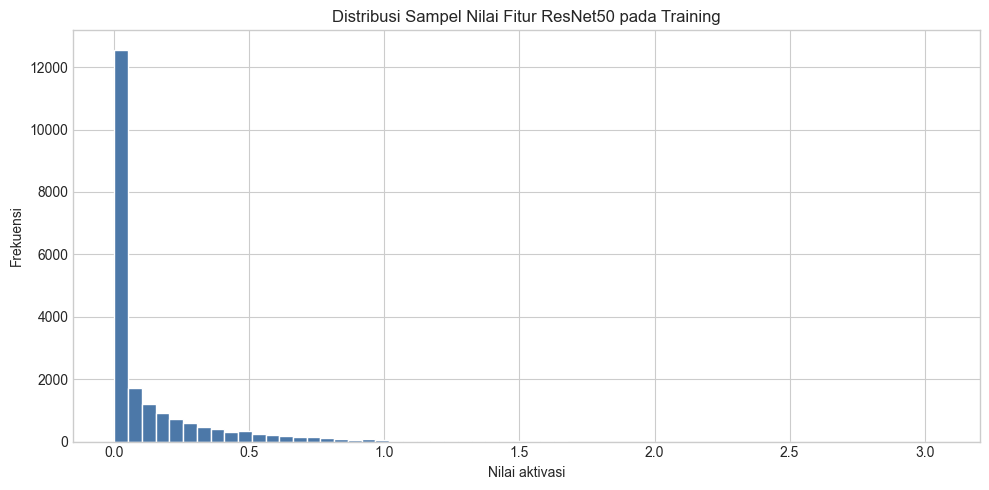

In [23]:
rng = np.random.default_rng(RANDOM_STATE)
selected_feature_indices = rng.choice(
    X_train_features.shape[1],
    size=min(12, X_train_features.shape[1]),
    replace=False,
)

plt.figure(figsize=(10, 5))
plt.hist(
    X_train_features[:, selected_feature_indices].ravel(),
    bins=60,
    color="#4C78A8",
    edgecolor="white",
)
plt.title("Distribusi Sampel Nilai Fitur ResNet50 pada Training")
plt.xlabel("Nilai aktivasi")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

## 13. Feature Scaling

SVM sensitif terhadap skala. StandardScaler selalu ditempatkan di dalam Pipeline sehingga hanya di-fit pada bagian training dari setiap fold. Test set hanya menerima transform dari scaler yang sudah di-fit.

In [24]:
cv = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}


def make_svm_pipeline(
    *,
    kernel: str = "rbf",
    use_pca: bool = False,
    probability: bool = False,
    cache_transforms: bool = False,
    **svc_kwargs,
) -> Pipeline:
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(
            (
                "pca",
                PCA(
                    n_components=0.95,
                    svd_solver="full",
                ),
            )
        )
    steps.append(
        (
            "svc",
            SVC(
                kernel=kernel,
                class_weight="balanced",
                probability=probability,
                random_state=RANDOM_STATE,
                **svc_kwargs,
            ),
        )
    )
    cache_location = str(PIPELINE_CACHE_DIR) if cache_transforms else None
    return Pipeline(steps, memory=cache_location)

## 14. Optional PCA Analysis

In [25]:
pca_probe_scaler = StandardScaler()
X_train_scaled_probe = pca_probe_scaler.fit_transform(X_train_features)

pca_probe = PCA(svd_solver="full")
pca_probe.fit(X_train_scaled_probe)
cumulative_variance = np.cumsum(pca_probe.explained_variance_ratio_)


def components_for_variance(target: float) -> int:
    return int(np.searchsorted(cumulative_variance, target) + 1)


pca_thresholds = pd.DataFrame(
    {
        "explained_variance": [0.90, 0.95, 0.99],
        "n_components": [
            components_for_variance(0.90),
            components_for_variance(0.95),
            components_for_variance(0.99),
        ],
    }
)
display(pca_thresholds)

,explained_variance,n_components
0,0.90,619
1,0.95,828
2,0.99,1210


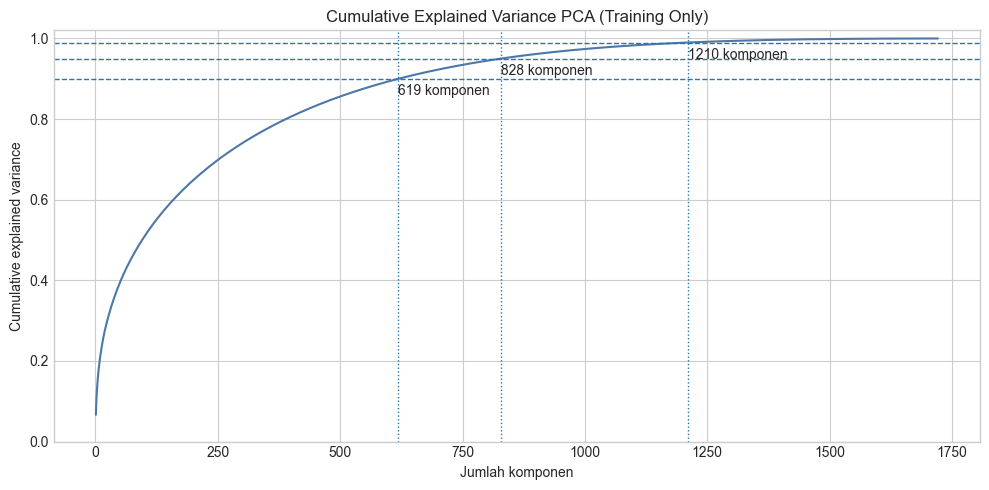

In [26]:
plt.figure(figsize=(10, 5))
component_axis = np.arange(1, len(cumulative_variance) + 1)
plt.plot(component_axis, cumulative_variance, color="#4C78A8")
for threshold in [0.90, 0.95, 0.99]:
    count = components_for_variance(threshold)
    plt.axhline(threshold, linestyle="--", linewidth=1)
    plt.axvline(count, linestyle=":", linewidth=1)
    plt.text(count, threshold - 0.04, f"{count} komponen")
plt.title("Cumulative Explained Variance PCA (Training Only)")
plt.xlabel("Jumlah komponen")
plt.ylabel("Cumulative explained variance")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

Perbandingan tanpa PCA vs PCA 95% dilakukan dengan cross-validation pada training. PCA berada di dalam pipeline, sehingga setiap fold hanya belajar dari subset train fold tersebut.

In [27]:
pca_comparison_records = []
pca_candidates = {
    "Tanpa PCA": make_svm_pipeline(
        use_pca=False,
        probability=False,
        cache_transforms=True,
    ),
    "PCA 95%": make_svm_pipeline(
        use_pca=True,
        probability=False,
        cache_transforms=True,
    ),
}

for experiment_name, candidate_pipeline in pca_candidates.items():
    scores = cross_validate(
        candidate_pipeline,
        X_train_features,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    pca_comparison_records.append(
        {
            "experiment": experiment_name,
            "mean_cv_accuracy": scores["test_accuracy"].mean(),
            "std_cv_accuracy": scores["test_accuracy"].std(),
            "mean_cv_balanced_accuracy": scores["test_balanced_accuracy"].mean(),
            "mean_cv_f1_macro": scores["test_f1_macro"].mean(),
            "std_cv_f1_macro": scores["test_f1_macro"].std(),
        }
    )

pca_comparison_df = pd.DataFrame(pca_comparison_records).sort_values(
    "mean_cv_f1_macro",
    ascending=False,
)
display(pca_comparison_df.style.format(precision=4))

,experiment,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,mean_cv_f1_macro,std_cv_f1_macro
1,PCA 95%,0.9709,0.0026,0.9462,0.9533,0.0097
0,Tanpa PCA,0.9471,0.0106,0.9056,0.9253,0.0165


In [28]:
no_pca_score = float(
    pca_comparison_df.loc[
        pca_comparison_df["experiment"] == "Tanpa PCA",
        "mean_cv_f1_macro",
    ].iloc[0]
)
pca_score = float(
    pca_comparison_df.loc[
        pca_comparison_df["experiment"] == "PCA 95%",
        "mean_cv_f1_macro",
    ].iloc[0]
)
pca_components_95 = components_for_variance(0.95)
compression_ratio = pca_components_95 / X_train_features.shape[1]

# PCA dipilih bila kehilangan Macro F1 maksimal 0.5 percentage point
# dan dimensinya turun setidaknya 25%.
USE_PCA_FINAL = bool(
    (pca_score >= no_pca_score - 0.005)
    and (compression_ratio <= 0.75)
)

print(f"Macro F1 tanpa PCA     : {no_pca_score:.4f}")
print(f"Macro F1 PCA 95%       : {pca_score:.4f}")
print(f"Komponen PCA 95%       : {pca_components_95} / {X_train_features.shape[1]}")
print(f"PCA dipakai final      : {USE_PCA_FINAL}")

del X_train_scaled_probe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Macro F1 tanpa PCA     : 0.9253
Macro F1 PCA 95%       : 0.9533
Komponen PCA 95%       : 828 / 2048
PCA dipakai final      : True


## 15. Baseline SVM

Baseline menggunakan RBF, class weight balanced, dan scaler dalam pipeline. Probability dimatikan selama CV agar lebih cepat; model final akan mengaktifkannya untuk confidence dan ROC-AUC.

In [29]:
baseline_pipeline = make_svm_pipeline(
    kernel="rbf",
    use_pca=USE_PCA_FINAL,
    probability=False,
    cache_transforms=True,
    C=1.0,
    gamma="scale",
)
baseline_cv_scores = cross_validate(
    baseline_pipeline,
    X_train_features,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=N_JOBS,
    return_train_score=False,
)

baseline_summary = pd.Series(
    {
        "mean_cv_accuracy": baseline_cv_scores["test_accuracy"].mean(),
        "std_cv_accuracy": baseline_cv_scores["test_accuracy"].std(),
        "mean_cv_balanced_accuracy": baseline_cv_scores[
            "test_balanced_accuracy"
        ].mean(),
        "mean_cv_f1_macro": baseline_cv_scores["test_f1_macro"].mean(),
        "std_cv_f1_macro": baseline_cv_scores["test_f1_macro"].std(),
    },
    name="Baseline RBF",
)
display(baseline_summary.to_frame().T.style.format(precision=4))

,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,mean_cv_f1_macro,std_cv_f1_macro
Baseline RBF,0.9709,0.0026,0.9462,0.9533,0.0097


## 16. SVM Kernel Comparison

In [30]:
kernel_records = []
for kernel_name in ["linear", "rbf", "poly"]:
    candidate_pipeline = make_svm_pipeline(
        kernel=kernel_name,
        use_pca=USE_PCA_FINAL,
        probability=False,
        cache_transforms=True,
    )
    scores = cross_validate(
        candidate_pipeline,
        X_train_features,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    kernel_records.append(
        {
            "kernel": kernel_name,
            "mean_cv_accuracy": scores["test_accuracy"].mean(),
            "std_cv_accuracy": scores["test_accuracy"].std(),
            "mean_cv_balanced_accuracy": scores[
                "test_balanced_accuracy"
            ].mean(),
            "std_cv_balanced_accuracy": scores[
                "test_balanced_accuracy"
            ].std(),
            "mean_cv_f1_macro": scores["test_f1_macro"].mean(),
            "std_cv_f1_macro": scores["test_f1_macro"].std(),
        }
    )

kernel_comparison_df = pd.DataFrame(kernel_records).sort_values(
    "mean_cv_f1_macro",
    ascending=False,
)
display(kernel_comparison_df.style.format(precision=4))

,kernel,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_f1_macro,std_cv_f1_macro
0,linear,0.9779,0.0060,0.9441,0.0224,0.9575,0.0115
1,rbf,0.9709,0.0026,0.9462,0.0260,0.9533,0.0097
2,poly,0.5886,0.0126,0.5507,0.0273,0.5474,0.0277


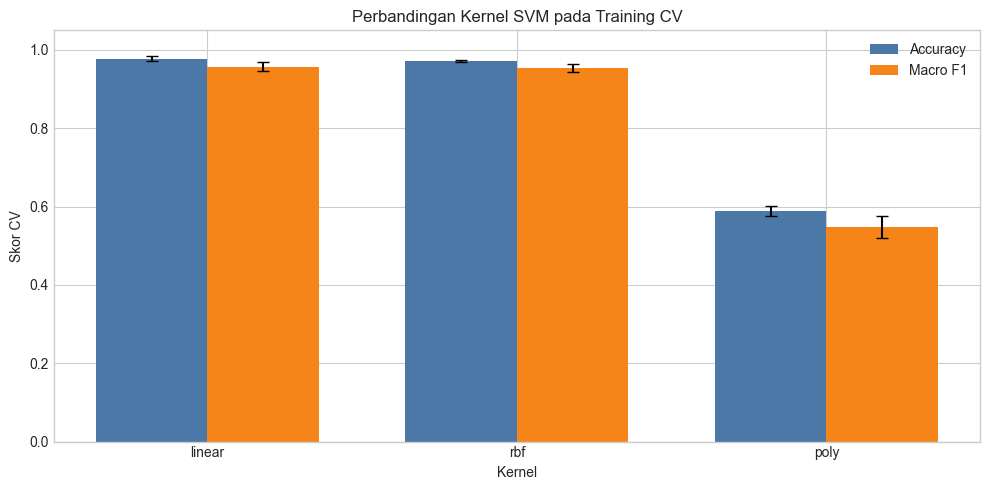

In [31]:
plot_df = kernel_comparison_df.set_index("kernel")
x_positions = np.arange(len(plot_df))
bar_width = 0.36

fig, axis = plt.subplots(figsize=(10, 5))
axis.bar(
    x_positions - bar_width / 2,
    plot_df["mean_cv_accuracy"],
    bar_width,
    yerr=plot_df["std_cv_accuracy"],
    label="Accuracy",
    color="#4C78A8",
    capsize=4,
)
axis.bar(
    x_positions + bar_width / 2,
    plot_df["mean_cv_f1_macro"],
    bar_width,
    yerr=plot_df["std_cv_f1_macro"],
    label="Macro F1",
    color="#F58518",
    capsize=4,
)
axis.set_title("Perbandingan Kernel SVM pada Training CV")
axis.set_xlabel("Kernel")
axis.set_ylabel("Skor CV")
axis.set_xticks(x_positions, plot_df.index)
axis.set_ylim(0, 1.05)
axis.legend()
plt.tight_layout()
plt.show()

## 17. Hyperparameter Tuning

Grid dipisahkan per kernel agar parameter yang tidak relevan tidak diuji. Seluruh pencarian memakai training set dan Stratified 5-Fold CV dengan Macro F1 sebagai objective.

In [32]:
search_pipeline = make_svm_pipeline(
    use_pca=USE_PCA_FINAL,
    probability=False,
    cache_transforms=True,
)

parameter_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": ["scale", 0.001, 0.01],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10],
        "svc__gamma": ["scale", 0.001],
        "svc__degree": [2, 3],
    },
]

grid_search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=N_JOBS,
    refit=True,
    return_train_score=True,
    verbose=1,
)
grid_search.fit(X_train_features, y_train)

print(f"Best CV Macro F1 : {grid_search.best_score_:.4f}")
print(f"Best parameters  : {grid_search.best_params_}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits


Best CV Macro F1 : 0.9580
Best parameters  : {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


In [33]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
parameter_columns = [
    column for column in cv_results_df.columns if column.startswith("param_")
]
top_search_results = (
    cv_results_df[
        parameter_columns
        + [
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "rank_test_score",
            "mean_fit_time",
        ]
    ]
    .sort_values(["rank_test_score", "mean_fit_time"])
    .head(10)
    .reset_index(drop=True)
)
display(top_search_results.style.format(precision=4))

,param_svc__C,param_svc__kernel,param_svc__gamma,param_svc__degree,mean_test_score,std_test_score,mean_train_score,rank_test_score,mean_fit_time
0,10.0000,rbf,scale,nan,0.9580,0.0145,1.0000,1,2.6847
1,100.0000,rbf,scale,nan,0.9576,0.0141,1.0000,2,3.0664
2,1.0000,linear,nan,nan,0.9575,0.0115,1.0000,3,1.4095
3,100.0000,linear,nan,nan,0.9575,0.0115,1.0000,3,1.4175
4,10.0000,linear,nan,nan,0.9575,0.0115,1.0000,3,1.4251
5,0.1000,linear,nan,nan,0.9575,0.0115,1.0000,3,1.4850
6,1.0000,rbf,scale,nan,0.9533,0.0097,0.9970,7,2.7994
7,10.0000,rbf,0.0010,nan,0.9327,0.0173,1.0000,8,4.5854
8,100.0000,rbf,0.0010,nan,0.9327,0.0173,1.0000,8,4.7904
9,1.0000,rbf,0.0010,nan,0.9255,0.0143,0.9984,10,4.5126


## 18. Final Model Training

Parameter terbaik hasil CV dipakai untuk membuat ulang pipeline dengan probability aktif. Pipeline final di-fit pada seluruh training set. Tidak ada informasi test yang digunakan pada tahap ini.

In [34]:
best_svc_params = {
    key.replace("svc__", ""): value
    for key, value in grid_search.best_params_.items()
}
best_kernel = best_svc_params.pop("kernel")

final_pipeline = make_svm_pipeline(
    kernel=best_kernel,
    use_pca=USE_PCA_FINAL,
    probability=True,
    **best_svc_params,
)

final_fit_start = time.perf_counter()
final_pipeline.fit(X_train_features, y_train)
final_fit_seconds = time.perf_counter() - final_fit_start

print(f"Final model selesai di-fit dalam {final_fit_seconds:.2f} detik.")
print(f"Urutan kelas model: {list(final_pipeline.classes_)}")

Final model selesai di-fit dalam 4.62 detik.
Urutan kelas model: ['Early Blight', 'Healthy', 'Late Blight']


## 19. Final Model Evaluation

**Mulai sel ini, test set dibuka untuk pertama kalinya dalam evaluasi model.** Prediksi dibuat satu kali lalu disimpan untuk seluruh analisis berikutnya.

In [35]:
y_pred = final_pipeline.predict(X_test_features)
y_proba = final_pipeline.predict_proba(X_test_features)
y_confidence = y_proba.max(axis=1)

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Macro Precision": precision_score(
        y_test, y_pred, average="macro", zero_division=0
    ),
    "Macro Recall": recall_score(
        y_test, y_pred, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_test, y_pred, average="macro", zero_division=0
    ),
    "Weighted Precision": precision_score(
        y_test, y_pred, average="weighted", zero_division=0
    ),
    "Weighted Recall": recall_score(
        y_test, y_pred, average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test, y_pred, average="weighted", zero_division=0
    ),
}
final_metrics_df = pd.DataFrame.from_dict(
    final_metrics,
    orient="index",
    columns=["Score"],
)
display(final_metrics_df.style.format("{:.4f}"))

,Score
Accuracy,0.9768
Balanced Accuracy,0.9379
Macro Precision,0.9839
Macro Recall,0.9379
Macro F1,0.9584
Weighted Precision,0.9776
Weighted Recall,0.9768
Weighted F1,0.9765


In [36]:
report_dict = classification_report(
    y_test,
    y_pred,
    labels=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
classification_report_df = pd.DataFrame(report_dict).T
display(classification_report_df.style.format(precision=4))

,precision,recall,f1-score,support
Early Blight,0.9949,0.9800,0.9874,200.0000
Late Blight,0.9567,0.9950,0.9755,200.0000
Healthy,1.0000,0.8387,0.9123,31.0000
accuracy,0.9768,0.9768,0.9768,0.9768
macro avg,0.9839,0.9379,0.9584,431.0000
weighted avg,0.9776,0.9768,0.9765,431.0000


## 20. Confusion Matrix

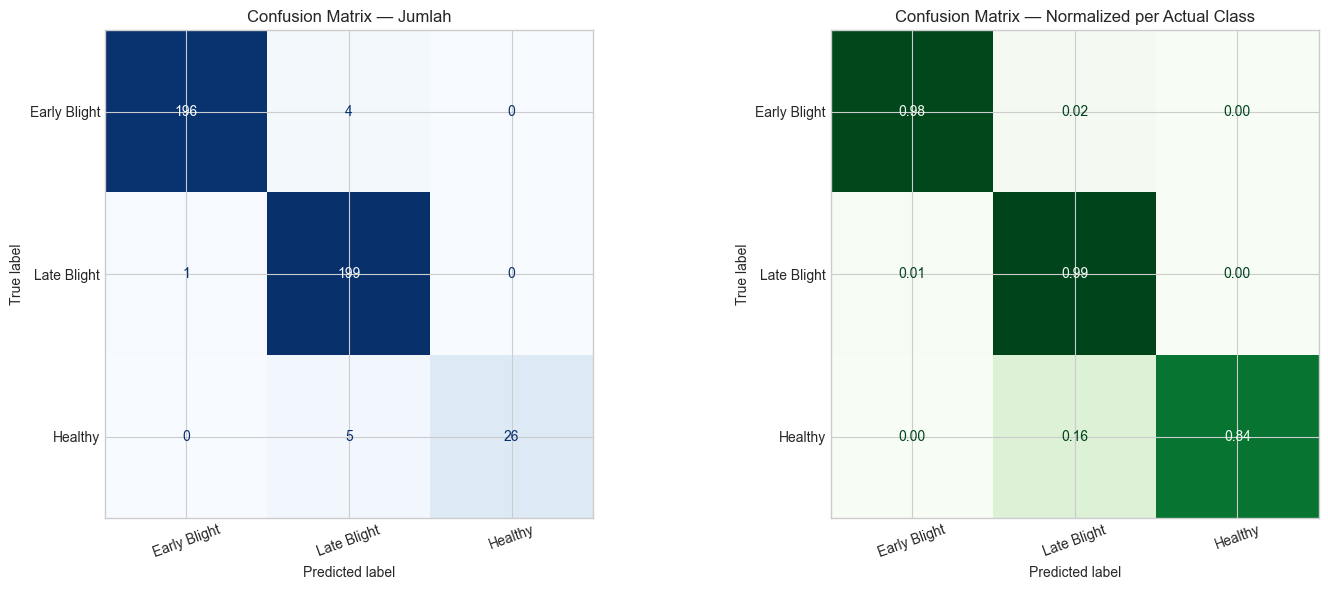

In [37]:
cm_raw = confusion_matrix(y_test, y_pred, labels=CLASS_NAMES)
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=CLASS_NAMES,
    normalize="true",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_raw,
    display_labels=CLASS_NAMES,
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format="d",
)
axes[0].set_title("Confusion Matrix — Jumlah")

ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=CLASS_NAMES,
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format=".2f",
)
axes[1].set_title("Confusion Matrix — Normalized per Actual Class")

for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 21. Per-Class Performance

In [38]:
per_class_df = pd.DataFrame(
    [
        {
            "Class": class_name,
            "Precision": report_dict[class_name]["precision"],
            "Recall": report_dict[class_name]["recall"],
            "F1-Score": report_dict[class_name]["f1-score"],
            "Support": int(report_dict[class_name]["support"]),
        }
        for class_name in CLASS_NAMES
    ]
)
display(
    per_class_df.style.format(
        {
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1-Score": "{:.4f}",
        }
    )
)

,Class,Precision,Recall,F1-Score,Support
0,Early Blight,0.9949,0.9800,0.9874,200
1,Late Blight,0.9567,0.9950,0.9755,200
2,Healthy,1.0000,0.8387,0.9123,31


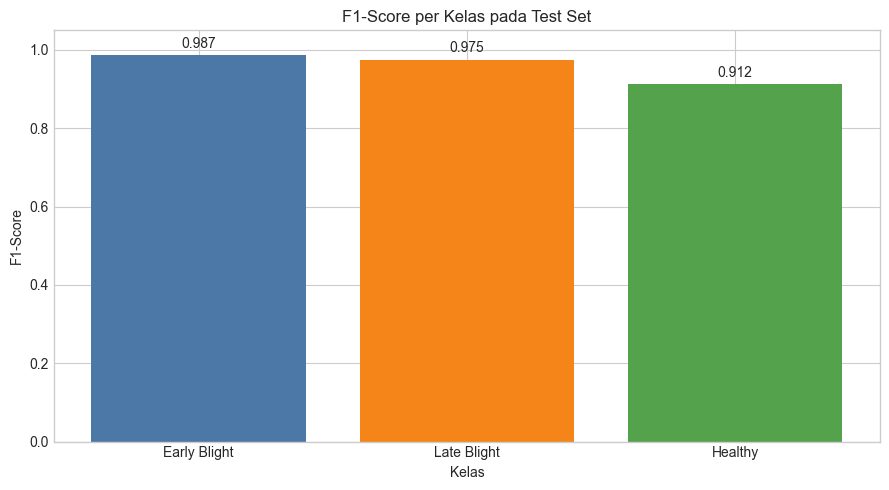

Kelas Healthy memiliki data paling sedikit. Test support=31, recall=0.8387, F1=0.9123.


In [39]:
fig, axis = plt.subplots(figsize=(9, 5))
bars = axis.bar(
    per_class_df["Class"],
    per_class_df["F1-Score"],
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axis.bar_label(bars, fmt="%.3f", padding=3)
axis.set_title("F1-Score per Kelas pada Test Set")
axis.set_xlabel("Kelas")
axis.set_ylabel("F1-Score")
axis.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

healthy_row = per_class_df.loc[per_class_df["Class"] == "Healthy"].iloc[0]
print(
    "Kelas Healthy memiliki data paling sedikit. "
    f"Test support={healthy_row['Support']}, "
    f"recall={healthy_row['Recall']:.4f}, "
    f"F1={healthy_row['F1-Score']:.4f}."
)

## 22. Multiclass ROC-AUC (One-vs-Rest)

Macro ROC-AUC OvR: 0.9986


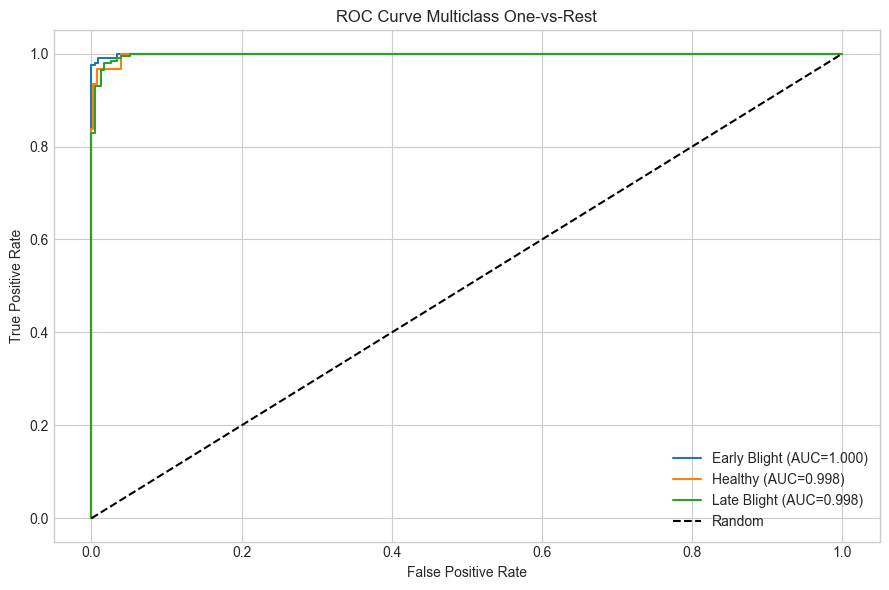

In [40]:
probability_classes = list(final_pipeline.classes_)
y_test_binary = label_binarize(y_test, classes=probability_classes)

macro_roc_auc = roc_auc_score(
    y_test_binary,
    y_proba,
    average="macro",
    multi_class="ovr",
)
final_metrics["Macro ROC-AUC OvR"] = macro_roc_auc
print(f"Macro ROC-AUC OvR: {macro_roc_auc:.4f}")

plt.figure(figsize=(9, 6))
for class_index, class_name in enumerate(probability_classes):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        y_proba[:, class_index],
    )
    class_auc = roc_auc_score(
        y_test_binary[:, class_index],
        y_proba[:, class_index],
    )
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{class_name} (AUC={class_auc:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random")
plt.title("ROC Curve Multiclass One-vs-Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Misclassification Analysis

Contoh salah prediksi membantu melihat pola visual yang membingungkan model dan menemukan kemungkinan noise atau kemiripan antarkelas.

In [41]:
test_results_df = pd.DataFrame(
    {
        "image_path": test_paths,
        "actual": y_test,
        "predicted": y_pred,
        "confidence": y_confidence,
        "correct": y_test == y_pred,
    }
)
misclassified_df = (
    test_results_df.loc[~test_results_df["correct"]]
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

print(f"Jumlah salah klasifikasi: {len(misclassified_df)} / {len(test_results_df)}")
display(misclassified_df.head(20))

Jumlah salah klasifikasi: 10 / 431


,image_path,actual,predicted,confidence,correct
0,dataset/Potato___healthy/762672f4-17e6-4fd6-84f1-3bcb091b3ca5___RS_HL 5417.JPG,Healthy,Late Blight,0.926483,False
1,dataset/Potato___Early_blight/66b6c6d1-fe63-4c7e-8054-bdf6ff67ff57___RS_Early.B 7514.JPG,Early Blight,Late Blight,0.830746,False
2,dataset/Potato___Early_blight/de1ff62e-87aa-420a-9eeb-cb0e3475e84d___RS_Early.B 6918.JPG,Early Blight,Late Blight,0.815582,False
3,dataset/Potato___Late_blight/17515ff9-075f-45a2-b8e6-1b8ba25c293d___RS_LB 4980.JPG,Late Blight,Early Blight,0.804118,False
4,dataset/Potato___Early_blight/7a8f295d-dc08-4a25-ba7a-28995729b6b6___RS_Early.B 8243.JPG,Early Blight,Late Blight,0.775393,False
5,dataset/Potato___healthy/413bc2e9-eb2a-48fd-ba65-48b5121fd85c___RS_HL 4200.JPG,Healthy,Late Blight,0.772046,False
6,dataset/Potato___healthy/9b5be0c5-7d7e-493d-88ba-c721c85f73ca___RS_HL 5405.JPG,Healthy,Late Blight,0.716563,False
7,dataset/Potato___Early_blight/68f056c9-4989-4809-b597-3739ff66afc3___RS_Early.B 8748.JPG,Early Blight,Late Blight,0.627886,False
8,dataset/Potato___healthy/7948ada9-eabc-4cb7-a579-b73e938eb716___RS_HL 4185.JPG,Healthy,Late Blight,0.602049,False
9,dataset/Potato___healthy/142fb983-2166-4a0f-b99b-a6c21e99987e___RS_HL 5398.JPG,Healthy,Late Blight,0.528471,False


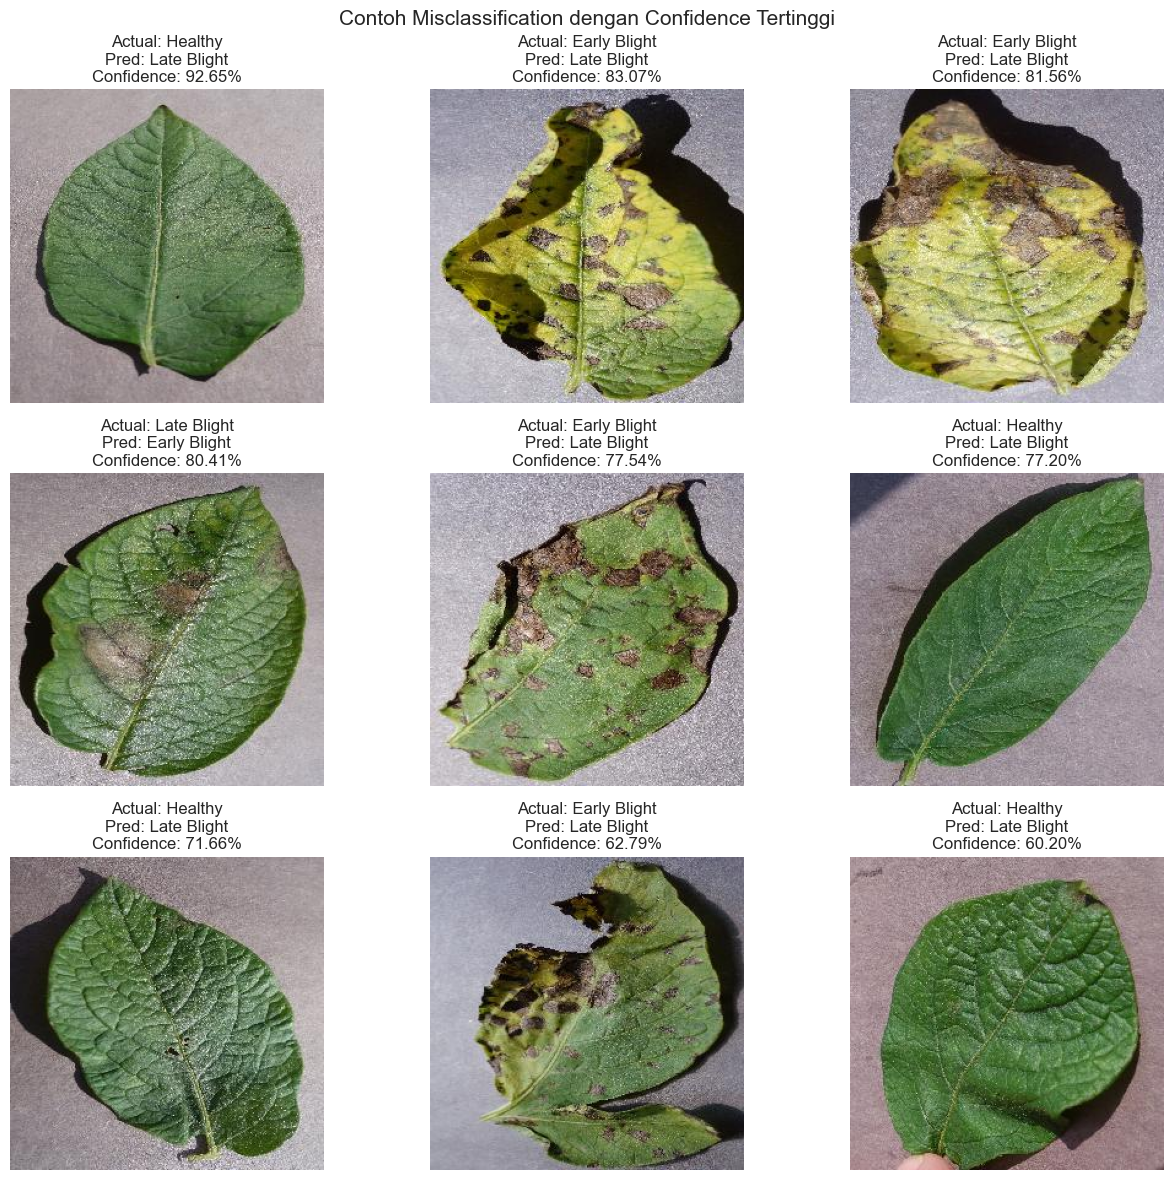

In [42]:
n_misclassified_examples = min(9, len(misclassified_df))

if n_misclassified_examples == 0:
    print("Tidak ada misclassification pada test set.")
else:
    figure, axes = plt.subplots(3, 3, figsize=(13, 12))
    axes = np.asarray(axes).ravel()

    for axis in axes:
        axis.axis("off")

    for index in range(n_misclassified_examples):
        row = misclassified_df.iloc[index]
        with Image.open(row["image_path"]) as image:
            axes[index].imshow(image.convert("RGB"))
        axes[index].set_title(
            f"Actual: {row['actual']}\n"
            f"Pred: {row['predicted']}\n"
            f"Confidence: {row['confidence']:.2%}"
        )
        axes[index].axis("off")

    figure.suptitle("Contoh Misclassification dengan Confidence Tertinggi", fontsize=15)
    plt.tight_layout()
    plt.show()

## 24. Confidence Analysis

In [43]:
correct_confidence = test_results_df.loc[
    test_results_df["correct"], "confidence"
]
incorrect_confidence = test_results_df.loc[
    ~test_results_df["correct"], "confidence"
]

confidence_summary = pd.DataFrame(
    {
        "Kelompok": ["Prediksi benar", "Prediksi salah"],
        "Jumlah": [len(correct_confidence), len(incorrect_confidence)],
        "Mean Confidence": [
            correct_confidence.mean(),
            incorrect_confidence.mean() if len(incorrect_confidence) else np.nan,
        ],
        "Median Confidence": [
            correct_confidence.median(),
            incorrect_confidence.median() if len(incorrect_confidence) else np.nan,
        ],
    }
)
display(confidence_summary.style.format(precision=4))

,Kelompok,Jumlah,Mean Confidence,Median Confidence
0,Prediksi benar,421,0.9786,0.9996
1,Prediksi salah,10,0.7399,0.7737


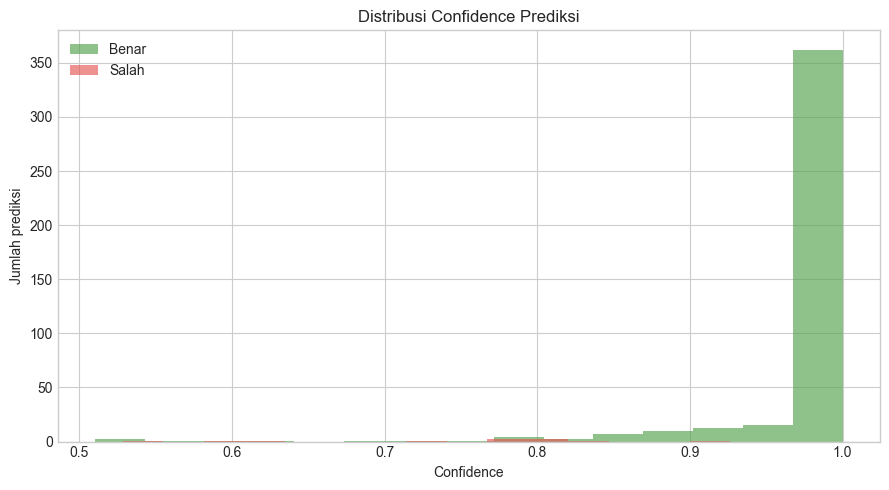

In [44]:
plt.figure(figsize=(9, 5))
plt.hist(
    correct_confidence,
    bins=15,
    alpha=0.65,
    label="Benar",
    color="#54A24B",
)
if len(incorrect_confidence):
    plt.hist(
        incorrect_confidence,
        bins=15,
        alpha=0.65,
        label="Salah",
        color="#E45756",
    )
plt.title("Distribusi Confidence Prediksi")
plt.xlabel("Confidence")
plt.ylabel("Jumlah prediksi")
plt.legend()
plt.tight_layout()
plt.show()

## 25. Prediction Function dan Random Test

In [45]:
def extract_single_feature(image: Image.Image) -> np.ndarray:
    rgb_image = image.convert("RGB")
    input_tensor = inference_preprocess(rgb_image).unsqueeze(0).to(device)

    feature_extractor.eval()
    with torch.inference_mode():
        feature = feature_extractor(input_tensor).flatten(start_dim=1)
    return feature.cpu().numpy().astype(np.float32)


def predict_image(image_path: str | Path) -> dict:
    with Image.open(image_path) as image:
        feature = extract_single_feature(image)

    prediction = final_pipeline.predict(feature)[0]
    probabilities = final_pipeline.predict_proba(feature)[0]
    probability_map = {
        class_name: float(probability)
        for class_name, probability in zip(
            final_pipeline.classes_,
            probabilities,
        )
    }
    return {
        "label": prediction,
        "confidence": probability_map[prediction],
        "probabilities": probability_map,
    }

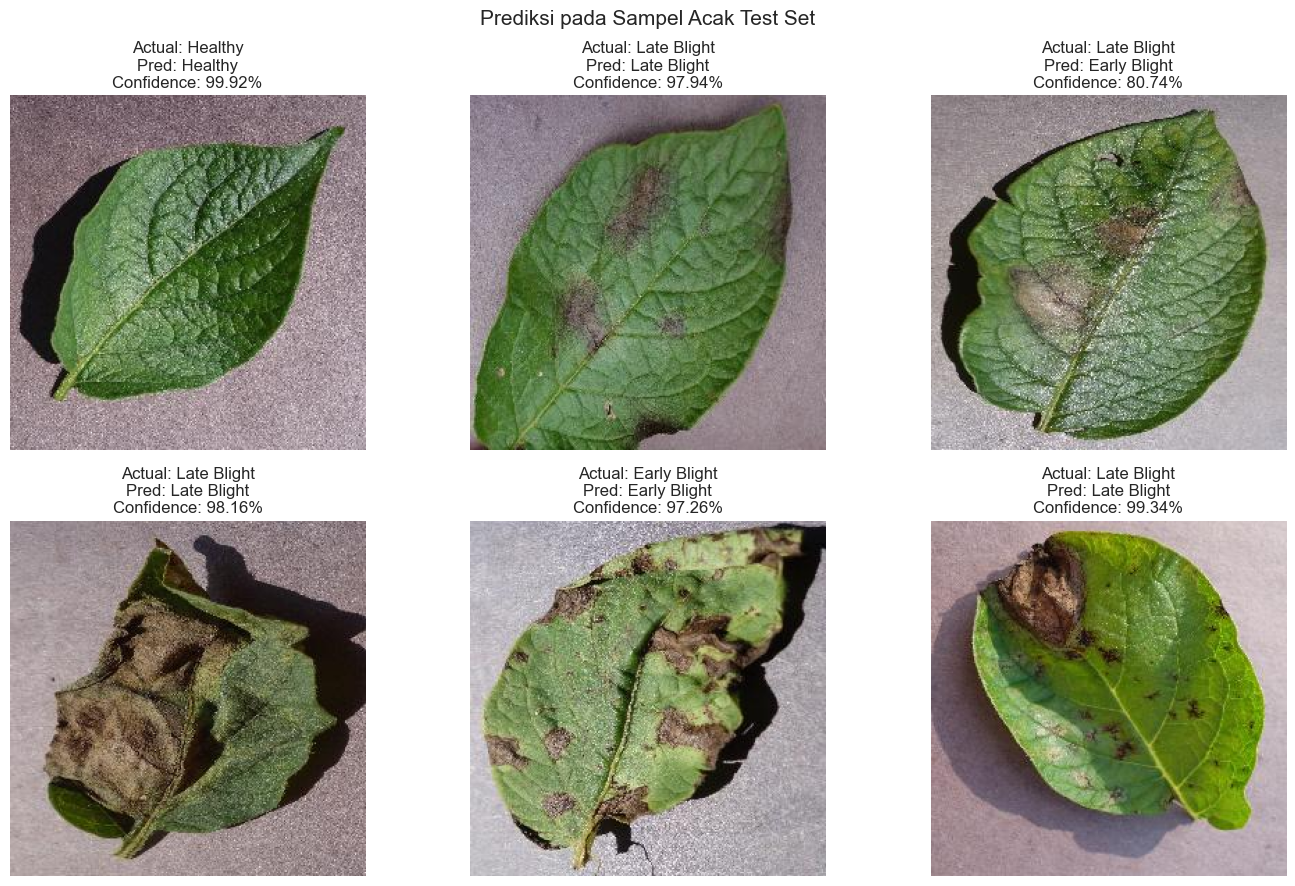

In [46]:
random_test_samples = test_df.sample(
    n=min(6, len(test_df)),
    random_state=RANDOM_STATE,
)
figure, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = np.asarray(axes).ravel()

for axis in axes:
    axis.axis("off")

for axis, (_, sample) in zip(axes, random_test_samples.iterrows()):
    prediction_result = predict_image(sample["image_path"])
    with Image.open(sample["image_path"]) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(
        f"Actual: {sample['label']}\n"
        f"Pred: {prediction_result['label']}\n"
        f"Confidence: {prediction_result['confidence']:.2%}"
    )
    axis.axis("off")

figure.suptitle("Prediksi pada Sampel Acak Test Set", fontsize=15)
plt.tight_layout()
plt.show()

## 26. Model Saving

In [47]:
def to_builtin(value):
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


pipeline_path = MODEL_DIR / "svm_pipeline.pkl"
metadata_path = MODEL_DIR / "model_metadata.json"

joblib.dump(final_pipeline, pipeline_path)

model_metadata = {
    "model_name": "Potato Leaf Disease Classification — ResNet50 + SVM",
    "feature_extractor": "torchvision.models.resnet50",
    "resnet50_weights": weights.name,
    "feature_dimension": int(X_train_features.shape[1]),
    "image_size": IMAGE_SIZE,
    "classes": list(final_pipeline.classes_),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "class_weight": "balanced",
    "pca_enabled": USE_PCA_FINAL,
    "pca_variance": 0.95 if USE_PCA_FINAL else None,
    "best_params": to_builtin(grid_search.best_params_),
    "best_cv_macro_f1": float(grid_search.best_score_),
    "test_metrics": to_builtin(final_metrics),
    "preprocessing": {
        "source": "ResNet50_Weights.DEFAULT.transforms()",
        "resize_size": list(inference_preprocess.resize_size),
        "crop_size": list(inference_preprocess.crop_size),
        "mean": list(inference_preprocess.mean),
        "std": list(inference_preprocess.std),
        "rgb_conversion": True,
    },
    "library_versions": {
        "python": sys.version.split()[0],
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "scikit_learn": sklearn.__version__,
    },
}

with metadata_path.open("w", encoding="utf-8") as metadata_file:
    json.dump(model_metadata, metadata_file, indent=2, ensure_ascii=False)

print(f"Pipeline tersimpan : {pipeline_path.resolve()}")
print(f"Metadata tersimpan : {metadata_path.resolve()}")

Pipeline tersimpan : D:\Arsip Hafizh Fadhl Muhammad\Project\kapita-selekta\models\svm_pipeline.pkl
Metadata tersimpan : D:\Arsip Hafizh Fadhl Muhammad\Project\kapita-selekta\models\model_metadata.json


## 27. Kesimpulan

In [48]:
pca_conclusion = (
    f"PCA 95% dipakai ({pca_components_95} komponen dari 2048)."
    if USE_PCA_FINAL
    else "PCA tidak dipakai karena trade-off CV/dimensionalitas tidak memenuhi aturan."
)

conclusion_text = (
    f"Pipeline akhir menggunakan fitur **ResNet50 ImageNet** dan "
    f"**SVM {best_kernel}**.\n\n"
    f"- Best CV Macro F1: **{grid_search.best_score_:.4f}**\n"
    f"- Test accuracy: **{final_metrics['Accuracy']:.4f}**\n"
    f"- Test balanced accuracy: **{final_metrics['Balanced Accuracy']:.4f}**\n"
    f"- Test Macro F1: **{final_metrics['Macro F1']:.4f}**\n"
    f"- Test Macro ROC-AUC OvR: **{final_metrics['Macro ROC-AUC OvR']:.4f}**\n"
    f"- {pca_conclusion}\n\n"
    "Class weight balanced dan metrik macro dipakai karena kelas Healthy "
    "jauh lebih sedikit. Nilai test merupakan evaluasi akhir, bukan dasar "
    "pemilihan model."
)
display(Markdown(conclusion_text))

Pipeline akhir menggunakan fitur **ResNet50 ImageNet** dan **SVM rbf**.

- Best CV Macro F1: **0.9580**
- Test accuracy: **0.9768**
- Test balanced accuracy: **0.9379**
- Test Macro F1: **0.9584**
- Test Macro ROC-AUC OvR: **0.9986**
- PCA 95% dipakai (828 komponen dari 2048).

Class weight balanced dan metrik macro dipakai karena kelas Healthy jauh lebih sedikit. Nilai test merupakan evaluasi akhir, bukan dasar pemilihan model.

## 28. Persiapan untuk Streamlit

File app.py memuat pipeline dengan joblib dan membangun ulang ResNet50 menggunakan weights yang tercatat pada metadata. Urutan inference harus selalu:

1. upload dan convert RGB;
2. preprocessing resmi weights ResNet50;
3. ekstraksi fitur 2048 dimensi;
4. final_pipeline.predict dan predict_proba.

Jalankan aplikasi setelah artefak model tersedia:

    streamlit run app.py

Aplikasi adalah prototype klasifikasi citra dan bukan pengganti pemeriksaan ahli pertanian.